# Presentation Resources - Model Comparison

This notebook provides a unified overview of all models used in the text analytics project, including key parameters, training methods, and performance characteristics.

## 1. N-Grams with TF-IDF

### Method Overview

N-grams capture sequences of consecutive words:
- **Unigrams** → "machine", "learning", "models"
- **Bigrams** → "machine learning", "learning models"
- **Trigrams** → "machine learning models"

**TF-IDF (Term Frequency-Inverse Document Frequency)** weights terms based on:
- How often they appear in a document (TF)
- How rare they are across all documents (IDF)

This emphasizes distinctive vocabulary while downweighting common words.

In [10]:
import json
from pathlib import Path

# Project root
project_root = Path.cwd().parent

# Load N-Grams metrics
ngrams_metrics_file = project_root / 'results' / 'ngrams' / 'ngrams_logistic_metrics.json'
with open(ngrams_metrics_file, 'r') as f:
    ngrams_metrics = json.load(f)

print("="*60)
print("N-GRAMS MODEL (Logistic Regression)")
print("="*60)
print("\n📊 MODEL PARAMETERS:")
print(f"  • N-gram range: (1, 3) - unigrams, bigrams, trigrams")
print(f"  • Max features: 10,000")
print(f"  • Min document frequency: 2")
print(f"  • Max document frequency: 0.95")
print(f"  • Classifier: Logistic Regression with balanced class weights")

print("\n🔧 TRAINING METHOD / LIBRARY:")
print(f"  • Feature extraction: scikit-learn TfidfVectorizer")
print(f"  • Classifier: scikit-learn LogisticRegression")
print(f"  • Solver: lbfgs (limited-memory BFGS)")

print("\n⏱️  TRAINING TIME:")
print(f"  • Total time: {ngrams_metrics.get('training_time_seconds', 0):.2f} seconds")

print("\n🎯 PERFORMANCE:")
print(f"  • Accuracy: {ngrams_metrics['accuracy']:.4f}")
print(f"  • Macro F1: {ngrams_metrics['macro_f1']:.4f}")
print("="*60)

N-GRAMS MODEL (Logistic Regression)

📊 MODEL PARAMETERS:
  • N-gram range: (1, 3) - unigrams, bigrams, trigrams
  • Max features: 10,000
  • Min document frequency: 2
  • Max document frequency: 0.95
  • Classifier: Logistic Regression with balanced class weights

🔧 TRAINING METHOD / LIBRARY:
  • Feature extraction: scikit-learn TfidfVectorizer
  • Classifier: scikit-learn LogisticRegression
  • Solver: lbfgs (limited-memory BFGS)

⏱️  TRAINING TIME:
  • Total time: 42.56 seconds

🎯 PERFORMANCE:
  • Accuracy: 0.8641
  • Macro F1: 0.8636


## 2. Word2Vec Embeddings

### Method Overview

**Word2Vec** learns dense vector representations (embeddings) of words by predicting context:
- Each word is mapped to a continuous vector (e.g., 200 dimensions)
- **Semantic relationships** are captured: words with similar meanings have similar vectors
- Example: `vector("king") - vector("man") + vector("woman") ≈ vector("queen")`

**Document representation:**
- Average all word vectors in a document to get document embedding
- This simple averaging approach loses word order information

**Limitation:** Generic semantic embeddings don't always capture task-specific patterns needed for classification.

In [11]:
# Load Word2Vec metrics
embeddings_metrics_file = project_root / 'results' / 'embeddings' / 'embeddings_word2vec_logistic_metrics.json'
with open(embeddings_metrics_file, 'r') as f:
    embeddings_metrics = json.load(f)

print("="*60)
print("WORD2VEC EMBEDDINGS MODEL")
print("="*60)
print("\n📊 MODEL PARAMETERS:")
print(f"  • Embedding dimensions: 200")
print(f"  • Vocabulary size: 45,693 words")
print(f"  • Window size: 5")
print(f"  • Min word count: 5")
print(f"  • Training epochs: 30")
print(f"  • Algorithm: Skip-gram")
print(f"  • Document pooling: Simple averaging (no TF-IDF)")
print(f"  • Classifier: Logistic Regression")

print("\n🔧 TRAINING METHOD / LIBRARY:")
print(f"  • Word embeddings: gensim Word2Vec")
print(f"  • Classifier: scikit-learn LogisticRegression")
print(f"  • Method: Train Word2Vec, average vectors per document, train classifier")

print("\n⏱️  TRAINING TIME:")
print(f"  • Total time: {embeddings_metrics.get('training_time_seconds', 0):.2f} seconds")

print("\n🎯 PERFORMANCE:")
print(f"  • Accuracy: {embeddings_metrics['accuracy']:.4f}")
print(f"  • Macro F1: {embeddings_metrics['macro_f1']:.4f}")
print("="*60)

WORD2VEC EMBEDDINGS MODEL

📊 MODEL PARAMETERS:
  • Embedding dimensions: 200
  • Vocabulary size: 45,693 words
  • Window size: 5
  • Min word count: 5
  • Training epochs: 30
  • Algorithm: Skip-gram
  • Document pooling: Simple averaging (no TF-IDF)
  • Classifier: Logistic Regression

🔧 TRAINING METHOD / LIBRARY:
  • Word embeddings: gensim Word2Vec
  • Classifier: scikit-learn LogisticRegression
  • Method: Train Word2Vec, average vectors per document, train classifier

⏱️  TRAINING TIME:
  • Total time: 7.48 seconds

🎯 PERFORMANCE:
  • Accuracy: 0.4885
  • Macro F1: 0.4831


## 3. LSTM (Long Short-Term Memory)

### Method Overview

**LSTM** is a type of Recurrent Neural Network (RNN) that processes sequences:
- Reads text **word by word** in sequence
- **Maintains memory** of previous words using hidden states
- **Bidirectional:** processes text both forwards and backwards
  - Forward: "The cat sat" → context flows left-to-right
  - Backward: "sat cat The" → context flows right-to-left

**Key capabilities:**
- Learns **task-specific word embeddings** (not pre-trained)
- Captures **word order** and **sequential patterns**
- Gates control what information to remember/forget
- Can handle long-range dependencies better than standard RNNs

**Architecture:** Embedding layer → Bidirectional LSTM (2 layers) → Dense classifier

In [12]:
# Load LSTM metrics
lstm_metrics_file = project_root / 'results' / 'lstm' / 'lstm_metrics.json'
with open(lstm_metrics_file, 'r') as f:
    lstm_metrics = json.load(f)

print("="*60)
print("LSTM MODEL (Bidirectional)")
print("="*60)
print("\n📊 MODEL PARAMETERS:")
print(f"  • Architecture: Bidirectional LSTM")
print(f"  • Number of layers: 2")
print(f"  • LSTM units per layer: 128 (256 total due to bidirectionality)")
print(f"  • Embedding dimensions: 200 (learned from scratch)")
print(f"  • Vocabulary size: 20,000 words")
print(f"  • Max sequence length: 250 tokens")
print(f"  • Dropout: 0.4")
print(f"  • Recurrent dropout: 0.2")

print("\n🔧 TRAINING METHOD / LIBRARY:")
print(f"  • Framework: TensorFlow / Keras")
print(f"  • Optimizer: Adam")
print(f"  • Loss function: Categorical crossentropy")
print(f"  • Early stopping: Yes (patience=3 on validation loss)")
print(f"  • Epochs trained: ~6 (stopped early)")

print("\n⏱️  TRAINING TIME:")
print(f"  • Total time: {lstm_metrics.get('training_time_seconds', 0):.2f} seconds")
print(f"  • Equivalent: {lstm_metrics.get('training_time_seconds', 0)/60:.1f} minutes (~{lstm_metrics.get('training_time_seconds', 0)/3600:.1f} hours)")

print("\n🎯 PERFORMANCE:")
print(f"  • Accuracy: {lstm_metrics['accuracy']:.4f}")
print(f"  • Macro F1: {lstm_metrics['macro_f1']:.4f}")
print("="*60)

LSTM MODEL (Bidirectional)

📊 MODEL PARAMETERS:
  • Architecture: Bidirectional LSTM
  • Number of layers: 2
  • LSTM units per layer: 128 (256 total due to bidirectionality)
  • Embedding dimensions: 200 (learned from scratch)
  • Vocabulary size: 20,000 words
  • Max sequence length: 250 tokens
  • Dropout: 0.4
  • Recurrent dropout: 0.2

🔧 TRAINING METHOD / LIBRARY:
  • Framework: TensorFlow / Keras
  • Optimizer: Adam
  • Loss function: Categorical crossentropy
  • Early stopping: Yes (patience=3 on validation loss)
  • Epochs trained: ~6 (stopped early)

⏱️  TRAINING TIME:
  • Total time: 22812.14 seconds
  • Equivalent: 380.2 minutes (~6.3 hours)

🎯 PERFORMANCE:
  • Accuracy: 0.8570
  • Macro F1: 0.8561


## 4. Transformer (DistilBERT)

### Method Overview

**Transformers** use **self-attention** mechanisms instead of recurrence:
- Processes all words **simultaneously** (parallel, not sequential)
- **Self-attention** allows each word to "attend to" all other words in the text
  - Example: In "The animal didn't cross the street because **it** was too tired"
  - Attention determines "it" refers to "animal" not "street"

**DistilBERT advantages:**
- **Pre-trained** on massive text corpora (knowledge transfer)
- **Contextual embeddings:** word meaning changes based on context
  - "bank" in "river bank" vs "bank account" → different vectors
- **Bidirectional context:** considers both left and right context simultaneously
- **Distilled:** 40% smaller and 60% faster than BERT, with 97% of performance

**Architecture:** DistilBERT base (6 transformer layers, 12 attention heads) + fine-tuned classification head

In [21]:
# Load Transformer metrics
transformer_metrics_file = project_root / 'results' / 'transformer' / 'transformer_metrics.json'
with open(transformer_metrics_file, 'r') as f:
    transformer_metrics = json.load(f)

print("="*60)
print("TRANSFORMER MODEL (DistilBERT)")
print("="*60)
print("\n📊 MODEL PARAMETERS:")
print(f"  • Base model: distilbert-base-uncased")
print(f"  • Total parameters: ~66 million (pre-trained)")
print(f"  • Transformer layers: 6")
print(f"  • Attention heads: 12")
print(f"  • Hidden size: 768")
print(f"  • Max sequence length: 512 tokens")
print(f"  • Vocabulary: 30'522 WordPiece tokens")

print("\n🔧 TRAINING METHOD / LIBRARY:")
print(f"  • Framework: PyTorch + Hugging Face Transformers")
print(f"  • Method: Fine-tuning (adapting pre-trained model)")
print(f"  • Optimizer: AdamW with gradient clipping")
print(f"  • Learning rate: 2e-5 with linear warmup (500 steps)")
print(f"  • Early stopping: Yes (patience=2 on validation loss)")
print(f"  • Epochs trained: ~4 (stopped early)")

print("\n⏱️  TRAINING TIME:")
print(f"  • Total time: {transformer_metrics.get('training_time_seconds', 0):.2f} seconds")
print(f"  • Equivalent: {transformer_metrics.get('training_time_seconds', 0)/60:.1f} minutes (~{transformer_metrics.get('training_time_seconds', 0)/3600:.1f} hours)")

print("\n🎯 PERFORMANCE:")
print(f"  • Accuracy: {transformer_metrics['accuracy']:.4f}")
print(f"  • Macro F1: {transformer_metrics['macro_f1']:.4f}")
print("="*60)

TRANSFORMER MODEL (DistilBERT)

📊 MODEL PARAMETERS:
  • Base model: distilbert-base-uncased
  • Total parameters: ~66 million (pre-trained)
  • Transformer layers: 6
  • Attention heads: 12
  • Hidden size: 768
  • Max sequence length: 512 tokens
  • Vocabulary: 30'522 WordPiece tokens

🔧 TRAINING METHOD / LIBRARY:
  • Framework: PyTorch + Hugging Face Transformers
  • Method: Fine-tuning (adapting pre-trained model)
  • Optimizer: AdamW with gradient clipping
  • Learning rate: 2e-5 with linear warmup (500 steps)
  • Early stopping: Yes (patience=2 on validation loss)
  • Epochs trained: ~4 (stopped early)

⏱️  TRAINING TIME:
  • Total time: 32139.74 seconds
  • Equivalent: 535.7 minutes (~8.9 hours)

🎯 PERFORMANCE:
  • Accuracy: 0.9153
  • Macro F1: 0.9137


## Summary Comparison

Quick comparison of all models:

In [14]:
import pandas as pd

# Create comparison table
comparison = pd.DataFrame({
    'Model': ['N-Grams', 'Word2Vec', 'LSTM', 'Transformer'],
    'Accuracy': [
        ngrams_metrics['accuracy'],
        embeddings_metrics['accuracy'],
        lstm_metrics['accuracy'],
        transformer_metrics['accuracy']
    ],
    'Macro F1': [
        ngrams_metrics['macro_f1'],
        embeddings_metrics['macro_f1'],
        lstm_metrics['macro_f1'],
        transformer_metrics['macro_f1']
    ],
    'Training Time (s)': [
        ngrams_metrics.get('training_time_seconds', 0),
        embeddings_metrics.get('training_time_seconds', 0),
        lstm_metrics.get('training_time_seconds', 0),
        transformer_metrics.get('training_time_seconds', 0)
    ],
    'Library': [
        'scikit-learn',
        'gensim + sklearn',
        'TensorFlow/Keras',
        'PyTorch/Transformers'
    ]
})

# Format the table
comparison['Accuracy'] = comparison['Accuracy'].apply(lambda x: f"{x:.4f}")
comparison['Macro F1'] = comparison['Macro F1'].apply(lambda x: f"{x:.4f}")
comparison['Training Time (s)'] = comparison['Training Time (s)'].apply(lambda x: f"{x:.2f}")

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Best model
best_idx = comparison['Macro F1'].astype(float).idxmax()
print(f"\n🏆 Best performing model: {comparison.loc[best_idx, 'Model']}")
print(f"   F1 Score: {comparison.loc[best_idx, 'Macro F1']}")


MODEL COMPARISON SUMMARY
      Model Accuracy Macro F1 Training Time (s)              Library
    N-Grams   0.8641   0.8636             42.56         scikit-learn
   Word2Vec   0.4885   0.4831              7.48     gensim + sklearn
       LSTM   0.8570   0.8561          22812.14     TensorFlow/Keras
Transformer   0.9153   0.9137          32139.74 PyTorch/Transformers

🏆 Best performing model: Transformer
   F1 Score: 0.9137


---

## Visualizations

### Zipf's Law and Dimensionality Reduction

The following visualizations help understand the data and model representations:

#### Zipf's Law

**Zipf's Law** states that the frequency of a word is inversely proportional to its rank:
- The most common word appears ~2x more than the 2nd most common
- The 2nd most common appears ~2x more than the 4th most common
- Forms a straight line on a log-log plot

This helps understand vocabulary distribution in the corpus.

#### N-Grams - Document Vectors Visualization

Visualizing TF-IDF document vectors in 2D (documents represented by N-gram features).
Documents are colored by their true topic labels to show clustering in the feature space.

In [ ]:
import pickle

# Load N-grams model
ngrams_model_path = project_root / 'models' / 'ngrams_logistic.pkl'
with open(ngrams_model_path, 'rb') as f:
    ngrams_model = pickle.load(f)

# Load validation data
_, val_df, _ = load_splits(str(data_dir))

# Sample documents for visualization (500 samples, ~71 per class)
sample_size = 500
sampled_df = val_df.groupby('unified_topic').apply(
    lambda x: x.sample(min(len(x), sample_size // 7), random_state=42)
).reset_index(drop=True)

print(f"Sampling {len(sampled_df)} documents for N-grams visualization")
print(f"Documents per topic: ~{len(sampled_df) // 7}")

# Transform documents to TF-IDF vectors
vectorizer = ngrams_model['vectorizer']
tfidf_vectors = vectorizer.transform(sampled_df['content'].tolist())

print(f"TF-IDF matrix shape: {tfidf_vectors.shape}")
print(f"Features (N-grams): {tfidf_vectors.shape[1]:,}")

# Convert sparse matrix to dense for dimensionality reduction
tfidf_dense = tfidf_vectors.toarray()

# Apply dimensionality reduction
print("\nComputing PCA...")
pca_ngrams = PCA(n_components=2, random_state=42)
pca_ngrams_result = pca_ngrams.fit_transform(tfidf_dense)

print("Computing t-SNE (this may take a minute)...")
tsne_ngrams = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_ngrams_result = tsne_ngrams.fit_transform(tfidf_dense)

# Visualize with topic colors
class_names = sorted(sampled_df['unified_topic'].unique())
colors_map = {topic: i for i, topic in enumerate(class_names)}
colors = [colors_map[topic] for topic in sampled_df['unified_topic']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
scatter1 = axes[0].scatter(pca_ngrams_result[:, 0], pca_ngrams_result[:, 1], 
                          c=colors, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('N-Grams Documents - PCA', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_ngrams.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_ngrams.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# t-SNE
scatter2 = axes[1].scatter(tsne_ngrams_result[:, 0], tsne_ngrams_result[:, 1], 
                          c=colors, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('N-Grams Documents - t-SNE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=plt.cm.tab10(i), markersize=8, label=topic)
                  for i, topic in enumerate(class_names)]
fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05), 
          ncol=7, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'presentation' / 'ngrams_dimensionality_reduction.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ N-grams document vectors visualized with PCA and t-SNE")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import sys
sys.path.insert(0, str(project_root / 'src'))
from data_splitting import load_splits
from preprocessing import TextPreprocessor

# Load training data
data_dir = project_root / 'data' / 'processed'
train_df, _, _ = load_splits(str(data_dir))

# Preprocess and get all words
preprocessor = TextPreprocessor(remove_stopwords=False, min_token_length=1)
train_texts = preprocessor.transform(train_df['content'].tolist())

# Count word frequencies
all_words = []
for text in train_texts:
    all_words.extend(text.split())

word_counts = Counter(all_words)
frequencies = sorted(word_counts.values(), reverse=True)
ranks = np.arange(1, len(frequencies) + 1)

# Create Zipf's law plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.plot(ranks[:1000], frequencies[:1000], 'b-', linewidth=1.5)
ax1.set_xlabel('Rank', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title("Zipf's Law - Linear Scale (Top 1000 words)", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Log-log scale (should show straight line if Zipf's law holds)
ax2.loglog(ranks, frequencies, 'r-', linewidth=1.5)
ax2.set_xlabel('Rank (log scale)', fontsize=12)
ax2.set_ylabel('Frequency (log scale)', fontsize=12)
ax2.set_title("Zipf's Law - Log-Log Scale (All words)", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(project_root / 'results' / 'presentation' / 'zipfs_law.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total unique words: {len(word_counts):,}")
print(f"Total word occurrences: {sum(frequencies):,}")
print(f"\nTop 10 most frequent words:")
for i, (word, count) in enumerate(word_counts.most_common(10), 1):
    print(f"  {i:2d}. '{word}': {count:,} occurrences")

#### Word2Vec - Word Embeddings Visualization

Visualizing 200-dimensional **word embeddings** in 2D (individual words, not documents):
- **PCA (Principal Component Analysis)**: Linear projection preserving maximum variance
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: Non-linear, preserves local structure

Note: Stopwords are filtered out to show only topic-relevant vocabulary.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from embeddings_model import EmbeddingsClassifier

# Use sklearn stopwords (same as preprocessing.py)
stop_words = set(ENGLISH_STOP_WORDS)

# Load Word2Vec model
w2v_model_path = project_root / 'models' / 'embeddings_word2vec_logistic.pkl'
w2v_model = EmbeddingsClassifier.load(str(w2v_model_path))

# Get word vectors for common words, excluding stopwords
sample_words = []
word_vectors = []
for word in w2v_model.word2vec_model.wv.index_to_key:
    # Skip stopwords and very short words
    if word not in stop_words and len(word) > 2:
        sample_words.append(word)
        word_vectors.append(w2v_model.word2vec_model.wv[word])
    
    # Stop when we have 1000 meaningful words
    if len(sample_words) >= 1000:
        break

word_vectors = np.array(word_vectors)

print(f"Visualizing {len(sample_words)} meaningful word embeddings (200 dimensions → 2D)")
print(f"(Stopwords removed to show topic-relevant vocabulary)")

# Apply dimensionality reduction
pca = PCA(n_components=2, random_state=42)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

print("\nComputing PCA...")
pca_result = pca.fit_transform(word_vectors)

print("Computing t-SNE (this may take a minute)...")
tsne_result = tsne.fit_transform(word_vectors)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
axes[0].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=10, c='steelblue')
axes[0].set_title('Word2Vec - PCA (Word Embeddings)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Annotate some sample words (more topic-relevant now)
sample_indices = [0, 5, 10, 20, 50, 100, 200, 500]
for idx in sample_indices:
    if idx < len(sample_words):
        axes[0].annotate(sample_words[idx], 
                        (pca_result[idx, 0], pca_result[idx, 1]),
                        fontsize=9, alpha=0.8, fontweight='bold')

# t-SNE
axes[1].scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5, s=10, c='steelblue')
axes[1].set_title('Word2Vec - t-SNE (Word Embeddings)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
axes[1].grid(True, alpha=0.3)

for idx in sample_indices:
    if idx < len(sample_words):
        axes[1].annotate(sample_words[idx], 
                        (tsne_result[idx, 0], tsne_result[idx, 1]),
                        fontsize=9, alpha=0.8, fontweight='bold')

plt.tight_layout()
plt.savefig(project_root / 'results' / 'presentation' / 'word2vec_word_embeddings.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Word2Vec word embeddings visualized with PCA and t-SNE (stopwords removed)")

#### Word2Vec - Document Embeddings Visualization

Visualizing document-level representations created by averaging word vectors.
Documents are colored by their true topic labels to show how well simple averaging creates topic separation.

In [ ]:
# Load validation data
_, val_df, _ = load_splits(str(data_dir))

# Sample documents for visualization (500 samples, ~71 per class)
sample_size = 500
sampled_df = val_df.groupby('unified_topic').apply(
    lambda x: x.sample(min(len(x), sample_size // 7), random_state=42)
).reset_index(drop=True)

print(f"Sampling {len(sampled_df)} documents for Word2Vec visualization")
print(f"Documents per topic: ~{len(sampled_df) // 7}")

# Preprocess texts
from preprocessing import TextPreprocessor
preprocessor = TextPreprocessor(remove_stopwords=True, min_token_length=2)
processed_texts = preprocessor.transform(sampled_df['content'].tolist())

# Create document embeddings by averaging word vectors
doc_embeddings = []
for text in processed_texts:
    tokens = text.split()
    
    # Get word vectors for tokens that exist in vocabulary
    vectors = []
    for token in tokens:
        if token in w2v_model.word2vec_model.wv:
            vectors.append(w2v_model.word2vec_model.wv[token])
    
    # Average vectors (or use zero vector if no words found)
    if len(vectors) > 0:
        doc_vector = np.mean(vectors, axis=0)
    else:
        doc_vector = np.zeros(w2v_model.vector_size)
    
    doc_embeddings.append(doc_vector)

doc_embeddings = np.array(doc_embeddings)

print(f"Document embeddings shape: {doc_embeddings.shape}")
print(f"Embedding dimensions: {doc_embeddings.shape[1]}")

# Apply dimensionality reduction
print("\nComputing PCA...")
pca_w2v_doc = PCA(n_components=2, random_state=42)
pca_w2v_doc_result = pca_w2v_doc.fit_transform(doc_embeddings)

print("Computing t-SNE (this may take a minute)...")
tsne_w2v_doc = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_w2v_doc_result = tsne_w2v_doc.fit_transform(doc_embeddings)

# Visualize with topic colors
class_names = sorted(sampled_df['unified_topic'].unique())
colors_map = {topic: i for i, topic in enumerate(class_names)}
colors = [colors_map[topic] for topic in sampled_df['unified_topic']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
scatter1 = axes[0].scatter(pca_w2v_doc_result[:, 0], pca_w2v_doc_result[:, 1], 
                          c=colors, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('Word2Vec Documents - PCA', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_w2v_doc.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_w2v_doc.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# t-SNE
scatter2 = axes[1].scatter(tsne_w2v_doc_result[:, 0], tsne_w2v_doc_result[:, 1], 
                          c=colors, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('Word2Vec Documents - t-SNE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=plt.cm.tab10(i), markersize=8, label=topic)
                  for i, topic in enumerate(class_names)]
fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05), 
          ncol=7, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'presentation' / 'word2vec_document_embeddings.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Word2Vec document embeddings visualized with PCA and t-SNE")

#### LSTM - Document Embeddings Visualization

Visualizing learned **document-level embeddings** from the LSTM model.
Documents are colored by their true topic labels to show clustering in the learned representation space.

In [ ]:
from lstm_model import LSTMClassifier
from tensorflow.keras.models import Model

# Load LSTM model
lstm_model_path = project_root / 'models' / 'lstm_model.pkl'
lstm_model = LSTMClassifier.load(str(lstm_model_path))

# Load validation data
_, val_df, _ = load_splits(str(data_dir))

# Sample documents for visualization (500 samples, ~71 per class)
sample_size = 500
sampled_df = val_df.groupby('unified_topic').apply(
    lambda x: x.sample(min(len(x), sample_size // 7), random_state=42)
).reset_index(drop=True)

print(f"Sampling {len(sampled_df)} documents for LSTM visualization")
print(f"Documents per topic: ~{len(sampled_df) // 7}")

# Preprocess texts (LSTM needs tokenized sequences)
from preprocessing import TextPreprocessor
preprocessor = TextPreprocessor(remove_stopwords=False, min_token_length=2)
processed_texts = preprocessor.transform(sampled_df['content'].tolist())

# Convert to sequences
sequences = lstm_model.tokenizer.texts_to_sequences(processed_texts)
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences = pad_sequences(
    sequences,
    maxlen=lstm_model.max_sequence_length,
    padding='post',
    truncating='post'
)

print(f"Sequence shape: {padded_sequences.shape}")

# Create intermediate model to extract document embeddings (output of last LSTM layer)
# The model structure is: Embedding -> BiLSTM_1 -> BiLSTM_2 -> Dropout -> Dense
# We want the output after BiLSTM_2 (before dropout and classification)
lstm_output_layer = lstm_model.model.get_layer('bilstm_2')
embedding_model = Model(
    inputs=lstm_model.model.input,
    outputs=lstm_output_layer.output
)

# Get document embeddings
print("Extracting document embeddings from LSTM...")
doc_embeddings = embedding_model.predict(padded_sequences, verbose=0)

print(f"Document embeddings shape: {doc_embeddings.shape}")
print(f"Embedding dimensions: {doc_embeddings.shape[1]} (2 × {lstm_model.lstm_units} units for bidirectional)")

# Apply dimensionality reduction
print("\nComputing PCA...")
pca_lstm = PCA(n_components=2, random_state=42)
pca_lstm_result = pca_lstm.fit_transform(doc_embeddings)

print("Computing t-SNE (this may take a minute)...")
tsne_lstm = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_lstm_result = tsne_lstm.fit_transform(doc_embeddings)

# Visualize with topic colors
class_names = sorted(sampled_df['unified_topic'].unique())
colors_map = {topic: i for i, topic in enumerate(class_names)}
colors = [colors_map[topic] for topic in sampled_df['unified_topic']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
scatter1 = axes[0].scatter(pca_lstm_result[:, 0], pca_lstm_result[:, 1], 
                          c=colors, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('LSTM Documents - PCA', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_lstm.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_lstm.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# t-SNE
scatter2 = axes[1].scatter(tsne_lstm_result[:, 0], tsne_lstm_result[:, 1], 
                          c=colors, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('LSTM Documents - t-SNE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=plt.cm.tab10(i), markersize=8, label=topic)
                  for i, topic in enumerate(class_names)]
fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05), 
          ncol=7, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'presentation' / 'lstm_dimensionality_reduction.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ LSTM document embeddings visualized with PCA and t-SNE")

#### Transformer (DistilBERT) - Document Embeddings

Visualizing document-level representations from DistilBERT (768 dimensions → 2D).
We'll encode sample documents and visualize them colored by their true topic labels.

In [ ]:
from transformer_model import TransformerClassifier
import seaborn as sns

# Load Transformer model
transformer_model_path = project_root / 'models' / 'transformer.pkl'
transformer_model = TransformerClassifier.load(str(transformer_model_path))

# Load validation data
_, val_df, _ = load_splits(str(data_dir))

# Sample documents for visualization (500 samples, ~71 per class)
sample_size = 500
sampled_df = val_df.groupby('unified_topic').apply(
    lambda x: x.sample(min(len(x), sample_size // 7), random_state=42)
).reset_index(drop=True)

print(f"Sampling {len(sampled_df)} documents for visualization")
print(f"Documents per topic: ~{len(sampled_df) // 7}")

# Get document embeddings from transformer
import torch
from torch.utils.data import DataLoader, TensorDataset

# Tokenize texts
encodings = transformer_model.tokenizer(
    sampled_df['content'].tolist(),
    truncation=True,
    padding=True,
    max_length=transformer_model.max_length,
    return_tensors='pt'
)

# Get embeddings (CLS token output from last layer)
transformer_model.model.eval()
with torch.no_grad():
    outputs = transformer_model.model.distilbert(
        input_ids=encodings['input_ids'].to(transformer_model.device),
        attention_mask=encodings['attention_mask'].to(transformer_model.device)
    )
    # Use [CLS] token embedding (first token)
    doc_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

print(f"Document embeddings shape: {doc_embeddings.shape}")

# Apply dimensionality reduction
print("\nComputing PCA...")
pca_transformer = PCA(n_components=2, random_state=42)
pca_transformer_result = pca_transformer.fit_transform(doc_embeddings)

print("Computing t-SNE (this may take a minute)...")
tsne_transformer = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_transformer_result = tsne_transformer.fit_transform(doc_embeddings)

# Visualize with topic colors
class_names = sorted(sampled_df['unified_topic'].unique())
colors_map = {topic: i for i, topic in enumerate(class_names)}
colors = [colors_map[topic] for topic in sampled_df['unified_topic']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
scatter1 = axes[0].scatter(pca_transformer_result[:, 0], pca_transformer_result[:, 1], 
                          c=colors, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('Transformer Documents - PCA', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_transformer.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_transformer.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# t-SNE
scatter2 = axes[1].scatter(tsne_transformer_result[:, 0], tsne_transformer_result[:, 1], 
                          c=colors, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('Transformer Documents - t-SNE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=plt.cm.tab10(i), markersize=8, label=topic)
                  for i, topic in enumerate(class_names)]
fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05), 
          ncol=7, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'presentation' / 'transformer_dimensionality_reduction.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Transformer document embeddings visualized with PCA and t-SNE")

## Confusion Matrix

In [32]:
# Generate confusion matrices for all 4 models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path

# Create output directory
output_dir = Path(project_root / 'results' / 'presentation')
output_dir.mkdir(parents=True, exist_ok=True)

def plot_confusion_matrix(y_true, y_pred, class_names, title, filename):
    """
    Create and save a confusion matrix with 5:4 aspect ratio and ColorBrewer colors.
    Shows proportions (0.00-1.00) normalized by row.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        class_names: List of class names
        title: Title for the plot
        filename: Filename to save the figure
    """
    # Calculate confusion matrix (raw counts)
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    
    # Normalize by row (each row sums to 1.0)
    # This shows: for each true class, what proportion was predicted as each class
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create figure with 5:4 aspect ratio
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot confusion matrix with ColorBrewer BuPu colors
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='BuPu', vmin=0, vmax=1)
    
    ax.grid(False)
    
    # Add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Proportion', rotation=-90, va="bottom")
    
    # Set ticks and labels
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           title=title,
           ylabel='True Label',
           xlabel='Predicted Label')
    
    # Rotate x-axis labels for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations with proportions
    thresh = 0.5  # Middle of 0-1 range
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{cm_normalized[i, j]:.2f}',
                   ha="center", va="center",
                   color="white" if cm_normalized[i, j] > thresh else "black",
                   fontsize=10)
    
    # Adjust layout to prevent label cutoff
    fig.tight_layout()
    
    # Save figure
    save_path = output_dir / filename
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Saved: {filename}")

print("Generating confusion matrices for all models...")
print("="*60)

Generating confusion matrices for all models...


In [33]:
# 1. N-Grams Confusion Matrix
print("\n1. N-Grams (Logistic Regression)...")

# Load model and get predictions
from ngrams_model import NGramClassifier

ngrams_model = NGramClassifier.load(str(project_root / 'models' / 'ngrams_logistic.pkl'))

# Load validation data
_, val_df, _ = load_splits(str(data_dir))
class_names = sorted(val_df['unified_topic'].unique())
val_true_labels = val_df['unified_topic'].values

# Get predictions
ngrams_predictions = ngrams_model.predict(val_df['content'])

# Plot confusion matrix
plot_confusion_matrix(
    val_true_labels,
    ngrams_predictions,
    class_names,
    'N-Grams',
    'ngrams_confusion_matrix.png'
)


1. N-Grams (Logistic Regression)...
✅ Loaded model from /Users/colinbolli/Documents/02_FHGR/HS24/Text Analytics/Project/text-analytics-project/models/ngrams_logistic.pkl
✅ Loaded train split: 56,111 samples
✅ Loaded validation split: 12,024 samples
✅ Loaded test split: 12,024 samples
✓ Saved: ngrams_confusion_matrix.png


In [34]:
# 2. Embeddings Word2Vec Confusion Matrix
print("\n2. Embeddings Word2Vec...")

# Preprocess texts (Word2Vec needs preprocessed text)
preprocessor_embeddings = TextPreprocessor(remove_stopwords=True, min_token_length=2)
val_texts_embeddings = preprocessor_embeddings.transform(val_df['content'].tolist())

# Load model and get predictions
embeddings_model = EmbeddingsClassifier.load(str(project_root / 'models' / 'embeddings_word2vec_logistic.pkl'))
embeddings_predictions = embeddings_model.predict(val_texts_embeddings)

# Plot confusion matrix
plot_confusion_matrix(
    val_true_labels,
    embeddings_predictions,
    class_names,
    'Embeddings Word2Vec',
    'embeddings_confusion_matrix.png'
)


2. Embeddings Word2Vec...
✅ Loaded model from /Users/colinbolli/Documents/02_FHGR/HS24/Text Analytics/Project/text-analytics-project/models/embeddings_word2vec_logistic.pkl
✓ Saved: embeddings_confusion_matrix.png


In [37]:
# 3. LSTM Confusion Matrix
# NOTE: LSTM prediction is extremely slow on large datasets (9+ hours for 12K samples)
# Using pre-computed confusion matrix values from results/lstm/lstm_confusion_matrix.png
# These values are based on the full validation set (12,024 samples)

print("\n3. LSTM...")
print("Using pre-computed confusion matrix values (hardcoded due to slow inference)")

# Hardcoded normalized confusion matrix from previous full validation run
# Order: Business, Entertainment, Health, Politics, Science, Sports, Technology
lstm_cm_normalized = np.array([
    [0.77, 0.02, 0.01, 0.04, 0.00, 0.01, 0.15],  # Business
    [0.00, 0.91, 0.00, 0.01, 0.00, 0.00, 0.07],  # Entertainment
    [0.01, 0.00, 0.88, 0.01, 0.07, 0.00, 0.03],  # Health
    [0.04, 0.02, 0.00, 0.87, 0.00, 0.02, 0.04],  # Politics
    [0.01, 0.01, 0.17, 0.02, 0.75, 0.00, 0.04],  # Science
    [0.00, 0.01, 0.00, 0.01, 0.00, 0.95, 0.02],  # Sports
    [0.03, 0.08, 0.03, 0.02, 0.00, 0.00, 0.83],  # Technology
])

# Create the visualization directly from the normalized matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Plot confusion matrix with ColorBrewer BuPu colors
im = ax.imshow(lstm_cm_normalized, interpolation='nearest', cmap='BuPu', vmin=0, vmax=1)
ax.grid(False)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Proportion', rotation=-90, va="bottom")

# Set ticks and labels
ax.set(xticks=np.arange(lstm_cm_normalized.shape[1]),
       yticks=np.arange(lstm_cm_normalized.shape[0]),
       xticklabels=class_names,
       yticklabels=class_names,
       title='LSTM',
       ylabel='True Label',
       xlabel='Predicted Label')

# Rotate x-axis labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations with proportions
thresh = 0.5
for i in range(lstm_cm_normalized.shape[0]):
    for j in range(lstm_cm_normalized.shape[1]):
        ax.text(j, i, f'{lstm_cm_normalized[i, j]:.2f}',
               ha="center", va="center",
               color="white" if lstm_cm_normalized[i, j] > thresh else "black",
               fontsize=10)

# Adjust layout and save
fig.tight_layout()
save_path = output_dir / 'lstm_confusion_matrix.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"✓ Saved: lstm_confusion_matrix.png (from hardcoded values)")


3. LSTM...
Using pre-computed confusion matrix values (hardcoded due to slow inference)
✓ Saved: lstm_confusion_matrix.png (from hardcoded values)


In [36]:
# 4. Transformer Confusion Matrix
print("\n4. Transformer (DistilBERT)...")

# Transformer uses raw text (no preprocessing)
val_texts_raw = val_df['content'].tolist()

# Load model and get predictions
transformer_model = TransformerClassifier.load(str(project_root / 'models' / 'transformer.pkl'))
transformer_predictions = transformer_model.predict(val_texts_raw, batch_size=16)

# Plot confusion matrix
plot_confusion_matrix(
    val_true_labels,
    transformer_predictions,
    class_names,
    'Transformer',
    'transformer_confusion_matrix.png'
)

print("\n" + "="*60)
print("✓ All confusion matrices generated successfully!")
print(f"✓ Saved to: {output_dir.absolute()}")
print("="*60)


4. Transformer (DistilBERT)...
Using device: mps
✅ Loaded model from /Users/colinbolli/Documents/02_FHGR/HS24/Text Analytics/Project/text-analytics-project/models/transformer_model
✅ Loaded metadata from /Users/colinbolli/Documents/02_FHGR/HS24/Text Analytics/Project/text-analytics-project/models/transformer.pkl
✓ Saved: transformer_confusion_matrix.png

✓ All confusion matrices generated successfully!
✓ Saved to: /Users/colinbolli/Documents/02_FHGR/HS24/Text Analytics/Project/text-analytics-project/results/presentation


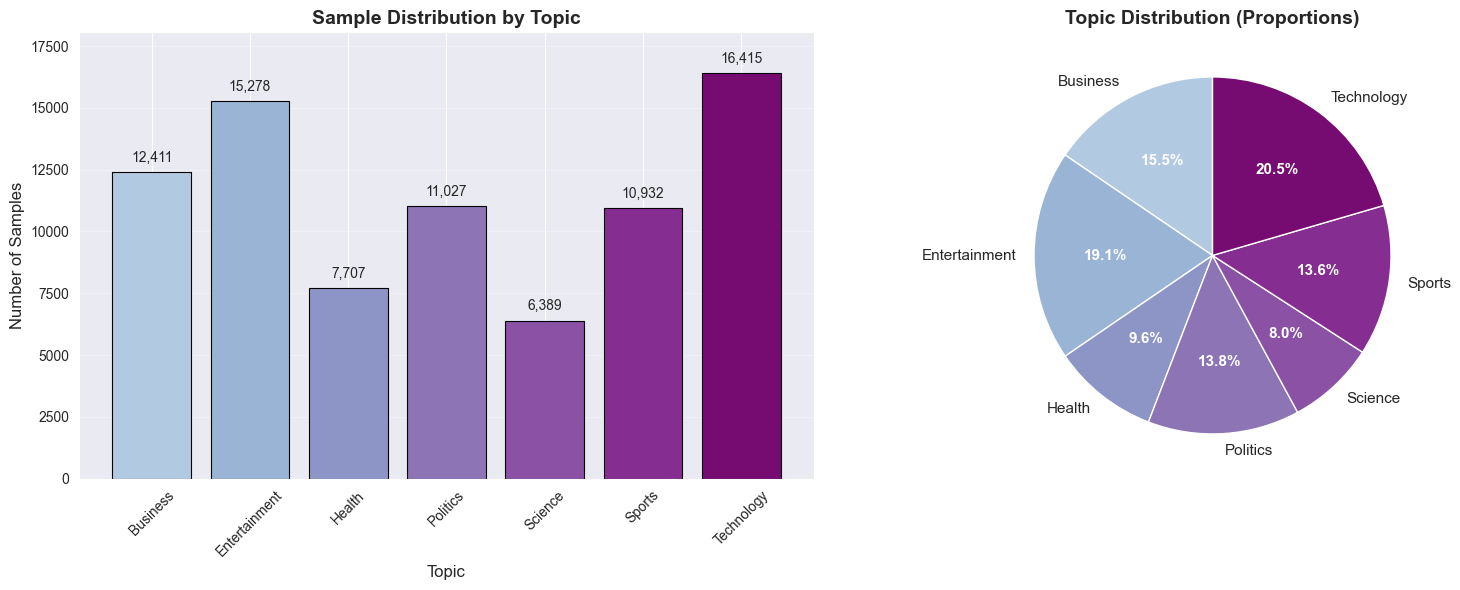

In [39]:
import matplotlib.pyplot as plt
import numpy as np

topics = ['Business', 'Entertainment', 'Health', 'Politics', 'Science', 'Sports', 'Technology']
samples = [12411, 15278, 7707, 11027, 6389, 10932, 16415]

total_samples = sum(samples)
proportions = [(s / total_samples) * 100 for s in samples]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cmap = plt.cm.BuPu
colors = cmap(np.linspace(0.3, 0.9, len(topics)))

ax1.bar(topics, samples, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_xlabel('Topic', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('Sample Distribution by Topic', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(samples) * 1.1)

for i, (topic, sample) in enumerate(zip(topics, samples)):
    ax1.text(i, sample + 300, f'{sample:,}', ha='center', va='bottom', fontsize=10)

ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

wedges, texts, autotexts = ax2.pie(
    samples,
    labels=topics,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11}
)

ax2.set_title('Topic Distribution (Proportions)', fontsize=14, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig(project_root / 'results' / 'presentation' / 'topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()